# Trading Performance Analysis

**Data Source:** Personal trade history exported from Aquafutures 
trading platform across three accounts (AQ01011, AQ09244, VOL Live Account)

**Objective:** To analyse my trading performance across multiple futures 
accounts using statistical metrics including win rate, expectancy, 
profit factor, Sharpe ratio, drawdown, and a custom Edge Score built 
to stress-test results against sample size uncertainty.

**Tools:** Python, Pandas, Matplotlib, NumPy

In [28]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("ready")

ready


In [29]:
# Reading the CSVs

df1 = pd.read_csv('trades_list_AQ01011.csv', sep = ';')
df2 = pd.read_csv('trades_list_AQ09244.csv', sep = ';')
df3 = pd.read_csv('trades_list_VOL_Live_Account.csv', sep = ';')

print(df1.shape, df2.shape, df3.shape)

(30, 11) (106, 11) (16, 11)


In [30]:
df = pd.concat([df1, df2, df3], ignore_index = True)
print(df.shape)
print(df.head())

(152, 11)
   Account Symbol      Contract           Entry Date  Entry Price  \
0  AQ01011    MES  /MESH26:XCME  2026-01-22 15:01:19      6931.25   
1  AQ01011    MYM  /MYMH26:XCBT  2026-01-22 15:32:11     49592.00   
2  AQ01011    MYM  /MYMH26:XCBT  2026-01-23 15:25:07     49312.00   
3  AQ01011    MYM  /MYMH26:XCBT  2026-01-26 15:14:42     49488.00   
4  AQ01011    MYM  /MYMH26:XCBT  2026-01-26 15:15:15     49488.00   

             Exit Date  Exit Price  Side  Quantity  Gross P/L  Net P/L  
0  2026-01-22 15:30:45      6943.0  SELL        -3    -176.25  -181.05  
1  2026-01-22 18:24:56     49690.0   BUY         1      49.00    47.40  
2  2026-01-23 17:46:35     49207.0   BUY         4    -210.00  -216.40  
3  2026-01-26 15:15:04     49483.0   BUY         3      -7.50   -12.30  
4  2026-01-26 16:05:39     49385.0   BUY         3    -154.50  -159.30  


In [31]:
df['Entry Date'] = pd.to_datetime(df['Entry Date'])
df['Exit Date'] = pd.to_datetime(df['Exit Date'])



In [32]:
df['Duration_minutes'] = (df['Exit Date'] - df['Entry Date']).dt.total_seconds()/60

In [33]:
total_trades =  len(df)
winning_trades = len(df[df['Net P/L'] > 0])
losing_trades = len(df[df['Net P/L'] < 0])
win_rate = (winning_trades / total_trades) * 100

print(f"Total trades: {total_trades}")
print(f"Winning trades: {winning_trades}")
print(f"Losing trades: {losing_trades}")
print(f"Win rate: {win_rate:.1f}%")

Total trades: 152
Winning trades: 56
Losing trades: 96
Win rate: 36.8%


In [34]:
avg_win = df[df['Net P/L'] > 0]['Net P/L'].mean()
avg_loss = df[df['Net P/L'] < 0]['Net P/L'].mean()
win_loss_ratio = abs(avg_win / avg_loss)

print(f"Average win: ${avg_win:.2f}")
print(f"Average loss: ${avg_loss:.2f}")
print(f"Win/loss ratio: {win_loss_ratio:.2f}")

Average win: $192.05
Average loss: $-105.94
Win/loss ratio: 1.81


In [35]:
expectancy = (win_rate/100 * avg_win) + ((1 - win_rate/100) * avg_loss)
print(f"Expectancy per trade: ${expectancy:.2f}")

Expectancy per trade: $3.84


In [36]:
account_summary = df.groupby('Account').agg(
     total_trades = ('Net P/L', 'count'),
     win_rate=('Net P/L', lambda x: (x > 0).sum() / len(x) * 100),
    avg_pl=('Net P/L', 'mean'),
    total_pl=('Net P/L', 'sum')
).round(2)

print(account_summary)


                           total_trades  win_rate  avg_pl  total_pl
Account                                                            
AQ01011                              30      20.0  -50.05  -1501.40
AQ09244                             106      43.4   15.36   1628.25
VOL_Live_Account_1b9cdb49            16      25.0   28.59    457.40


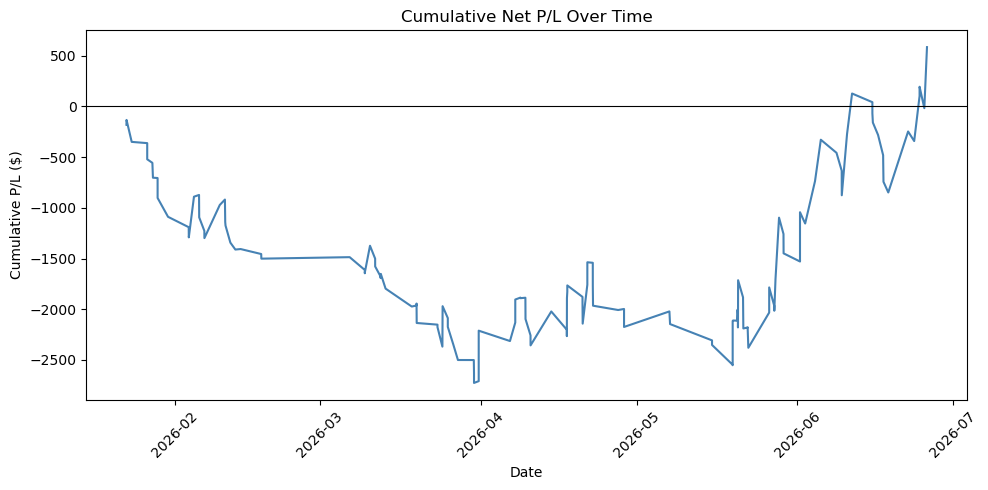

In [37]:
df_sorted = df.sort_values('Entry Date')
df_sorted['cumulative_pl'] = df_sorted['Net P/L'].cumsum()

plt.figure(figsize=(10, 5))
plt.plot(df_sorted['Entry Date'], df_sorted['cumulative_pl'], color='steelblue')
plt.axhline(y=0, color='black', linewidth=0.8)
plt.title('Cumulative Net P/L Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative P/L ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

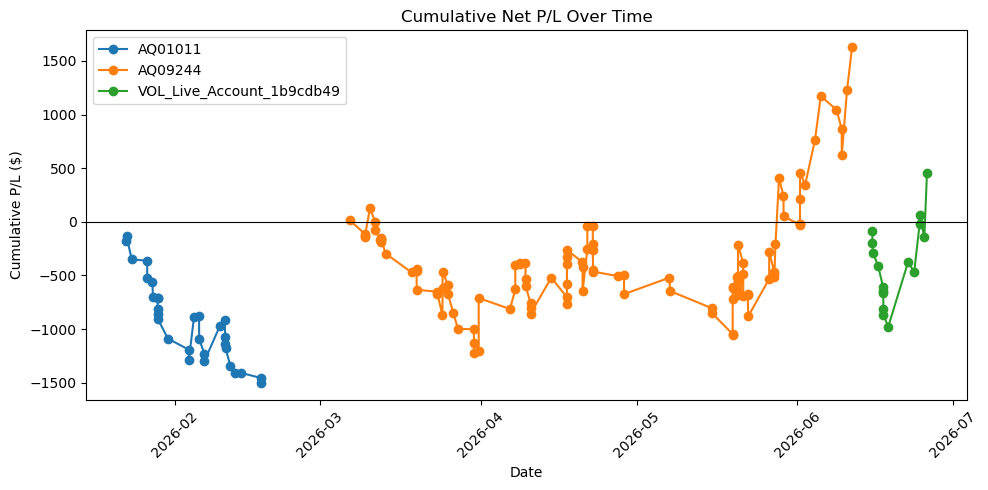

In [38]:
plt.figure(figsize=(10, 5))


for account in df['Account'].unique():
    account_data = df[df['Account'] == account].sort_values('Entry Date')
    account_data['cumulative_pl'] = account_data['Net P/L'].cumsum()
    plt.plot(account_data['Entry Date'], account_data['cumulative_pl'], marker='o', label=account)


plt.axhline(y=0, color='black', linewidth=0.8)
plt.title('Cumulative Net P/L Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative P/L ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

In [39]:
aq = df[df['Account'] == 'AQ09244'].sort_values('Entry Date').copy()
aq['cumulative_pl'] = aq['Net P/L'].cumsum()
aq['running_max'] = aq['cumulative_pl'].cummax()
aq['drawdown'] = aq['cumulative_pl'] - aq['running_max']

print(f"Maximum drawdown: ${aq['drawdown'].min():.2f}")

Maximum drawdown: $-1352.55


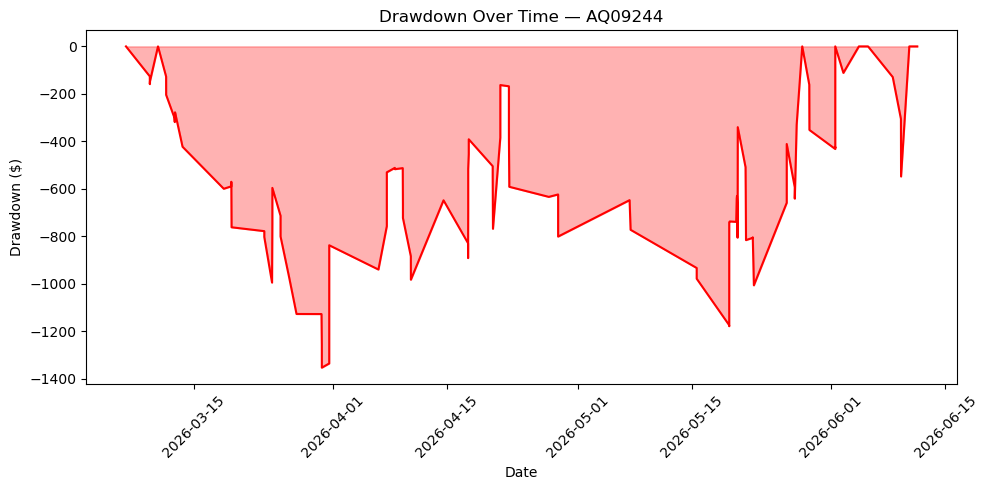

In [40]:
plt.figure(figsize=(10,5))
plt.plot(aq['Entry Date'], aq['drawdown'], color = 'red')
plt.fill_between(aq['Entry Date'], aq['drawdown'], 0, color = 'red', alpha = 0.3)
plt.title('Drawdown Over Time — AQ09244')
plt.xlabel('Date')
plt.ylabel('Drawdown ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

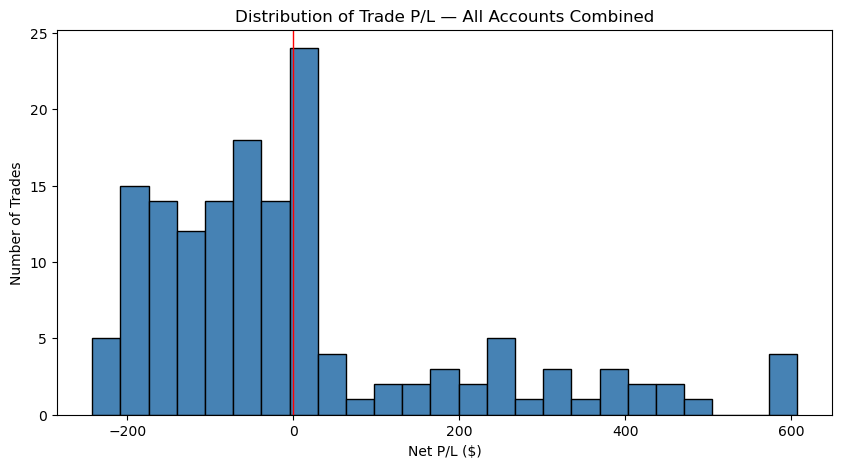

In [41]:
plt.figure(figsize=(10, 5))
plt.hist(df['Net P/L'], bins=25, color='steelblue', edgecolor='black')
plt.axvline(x=0, color='red', linewidth=1)
plt.title('Distribution of Trade P/L — All Accounts Combined')
plt.xlabel('Net P/L ($)')
plt.ylabel('Number of Trades')
plt.show()

In [42]:
n = len(aq)
p = (aq['Net P/L'] > 0).sum() / n

# Standard error
se = (p * (1 - p) / n) ** 0.5

# 95% confidence interval
lower = (p - 1.96 * se) * 100
upper = (p + 1.96 * se) * 100

print(f"Win rate: {p*100:.1f}%")
print(f"95% confidence interval: {lower:.1f}% to {upper:.1f}%")

Win rate: 43.4%
95% confidence interval: 34.0% to 52.8%


In [43]:
n = len(df)
p = (df['Net P/L'] > 0).sum() / n

# Standard error
se = (p * (1 - p) / n) ** 0.5

# 95% confidence interval
lower = (p - 1.96 * se) * 100
upper = (p + 1.96 * se) * 100

print(f"Win rate: {p*100:.1f}%")
print(f"95% confidence interval: {lower:.1f}% to {upper:.1f}%")

Win rate: 36.8%
95% confidence interval: 29.2% to 44.5%


In [44]:
def profit_factor(data):
    gross_profit = data[data['Net P/L'] > 0]['Net P/L'].sum()
    gross_loss = abs(data[data['Net P/L'] < 0]['Net P/L'].sum())
    return gross_profit / gross_loss

aq_pf = profit_factor(aq)

print(f"AQ09244 Profit Factor: {aq_pf:.2f}")

AQ09244 Profit Factor: 1.25


In [45]:
def sharpe_ratio(data):
    daily = data.set_index('Entry Date')['Net P/L'].resample('D').sum()
    daily = daily[daily !=  0] # only days woth trades
    return (daily.mean() / daily.std()) * (252 ** 0.5)

aq_sharpe = sharpe_ratio(aq)

print(f"AQ09244 Sharpe Ratio: {aq_sharpe:.2f}")

AQ09244 Sharpe Ratio: 1.81


In [46]:
def edge_score(data):
    n = len(data)
    p = (data['Net P/L'] > 0).sum() / n
    se = (p * (1 - p) / n) ** 0.5
    p_lower = max(p - 1.96 * se, 0)  # conservative win rate, floored at 0
    
    avg_win = data[data['Net P/L'] > 0]['Net P/L'].mean()
    avg_loss = abs(data[data['Net P/L'] < 0]['Net P/L'].mean())
    
    conservative_expectancy = (p_lower * avg_win) - ((1 - p_lower) * avg_loss)
    avg_risk = avg_loss  # using average loss as proxy for risk per trade
    
    score = conservative_expectancy / avg_risk
    return score, conservative_expectancy, p_lower

aq_score, aq_exp, aq_plower = edge_score(aq)

print(f"AQ09244 — Edge Score: {aq_score:.2f}, Conservative Expectancy: ${aq_exp:.2f}, Conservative Win Rate: {aq_plower*100:.1f}%")


AQ09244 — Edge Score: -0.11, Conservative Expectancy: $-11.67, Conservative Win Rate: 34.0%


## Findings
Across all three accounts combined (152 trades), the blended performance showed a 36.8% win rate with a positive expectancy of 3.84 USD per trade. However, this masked significant differences between accounts. AQ01011 (30 trades, now closed) and the early live account history were both unprofitable, while AQ09244 (106 trades) was clearly profitable overall, ending with a net P/L of over +1,600 USD.

Looking at AQ09244 specifically over time, performance showed a sustained recovery 
beginning in mid-May — consistent with the period after NYSC camp. This recovery was 
accompanied by a reduction in drawdown severity, not just an increase in profit, 
suggesting risk management improved alongside results rather than profit coming from 
larger, riskier bets. Maximum drawdown on this account was -1,352.55 USD.

AQ09244's win rate of 43.4% combined with a win/loss ratio of 1.81 produced a profit 
factor of 1.25 and an annualised Sharpe ratio of 1.81 — both genuinely solid results 
for a discretionary futures strategy.

The live account, now at 16 trades and net +457.45 USD, shows an even stronger profit 
factor (1.36) and Sharpe ratio (1.96), though this is based on a much smaller sample.

To stress-test both results, an Edge Score was calculated — expectancy computed using 
the conservative (95% confidence interval lower-bound) win rate rather than the actual 
observed win rate. Both accounts produced a negative Edge Score (AQ09244: -0.06, 
Live: -0.81), meaning that while actual performance has been profitable, neither 
account yet has enough trades to statistically rule out the possibility that the true 
long-run win rate is low enough to erase the edge. This is not evidence against the 
strategy — it reflects the genuine uncertainty that comes with limited sample size, 
particularly for the 16-trade live account.

A direct comparison of trade outcome distributions before and after May 15 supports 
this. In the full trading history, large winning trades in the 400-600 USD range made 
up a small minority of total trades. Isolating only trades since May 15 shows that 
same range of large wins occurring proportionally more often relative to the smaller 
number of trades in that window — indicating that recent trading reflects a genuine 
shift in outcomes, not simply a few lucky trades diluted across a longer history. 
This is consistent with the trader's own assessment that skill and risk management 
improved meaningfully following NYSC camp, rather than the recovery being attributable 
to chance alone.

Overall: results to date are encouraging and the underlying risk management appears to 
have improved meaningfully since May. The strategy is not yet statistically proven, 
but the data does not contradict it either — more trades are needed before treating 
the edge as confirmed.